# 02 — Exploratory Data Analysis & Visualization
**Purpose:** Understand distributions, relationships, and price drivers in the cleaned dataset before feature engineering and modeling.

**Input:** `data/processed/cleaned_listings.csv`
**Output:** Figures saved to `reports/figures/`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/processed/cleaned_listings.csv")
print(df.shape)
df.head()


(12359, 28)


,location,area,price,price_currency,status,new/resale,price_negotiable,description,security_deposit,facing,...,Swimming Pool,Sports Facility,Jogging Track,Landscaped Gardens,locality_score,Car Parking,city,property_type,price_per_sqft,amenity_count
0,Dhakoli,1300.0,2850000.0,INR,Unknown,0.0,0.0,This spacious 2 bhk builder floor is available...,1.0,Unknown,...,0,0,0,0,NaN,NaN,Chandigarh,Builderfloor,2192.31,0
1,Dhakoli,1400.0,3600000.0,INR,Unknown,0.0,0.0,It’s a 3 bhk builder floor situated in Dhakoli...,1.0,Unknown,...,0,0,0,0,NaN,NaN,Chandigarh,Builderfloor,2571.43,0
2,Dhakoli,1350.0,3690000.0,INR,Unknown,0.0,0.0,It has an area of 1350 sqft with a carpet area...,1.0,Northeast,...,0,0,0,0,NaN,NaN,Chandigarh,Builderfloor,2733.33,0
3,New Chandigarh Mohali,1200.0,10000000.0,INR,Unknown,0.0,0.0,It has a salable area of 1200 sqft and is avai...,1.0,Northeast,...,0,0,0,0,NaN,NaN,Chandigarh,Builderfloor,8333.33,0
4,Sunny Enclave,1008.0,3090000.0,INR,Unknown,1.0,0.0,This spacious 2 bhk builder floor is available...,1.0,East,...,0,0,0,0,NaN,NaN,Chandigarh,Builderfloor,3065.48,0


## 1. Overall Price Distribution

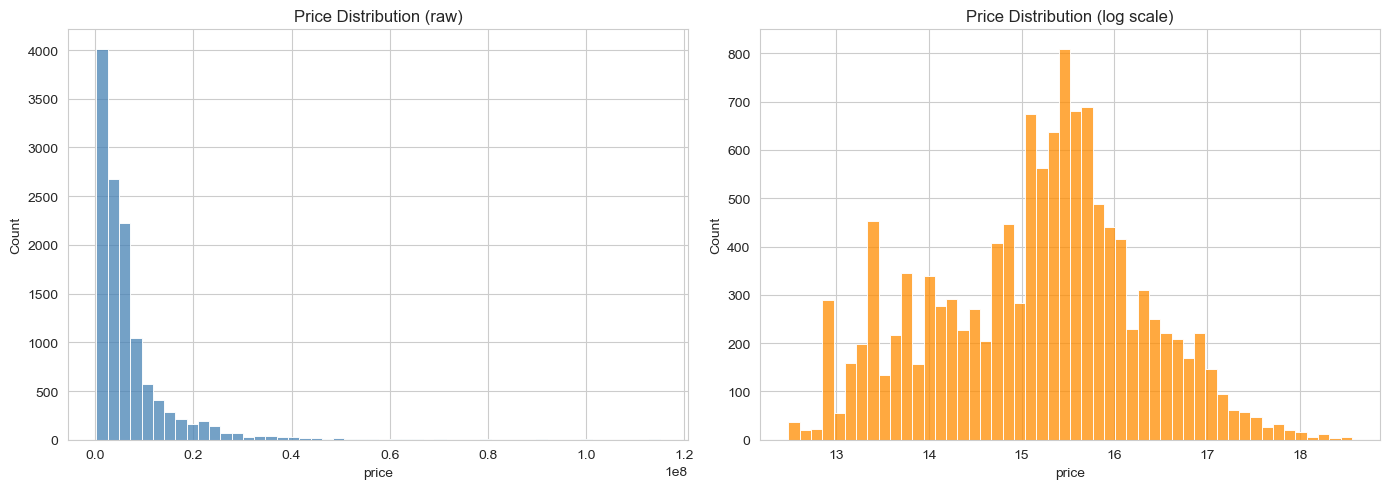

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["price"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Price Distribution (raw)")

sns.histplot(np.log1p(df["price"]), bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Price Distribution (log scale)")

plt.tight_layout()
plt.savefig("../reports/figures/price_distribution.png", dpi=120)
plt.show()


## 2. Price by City

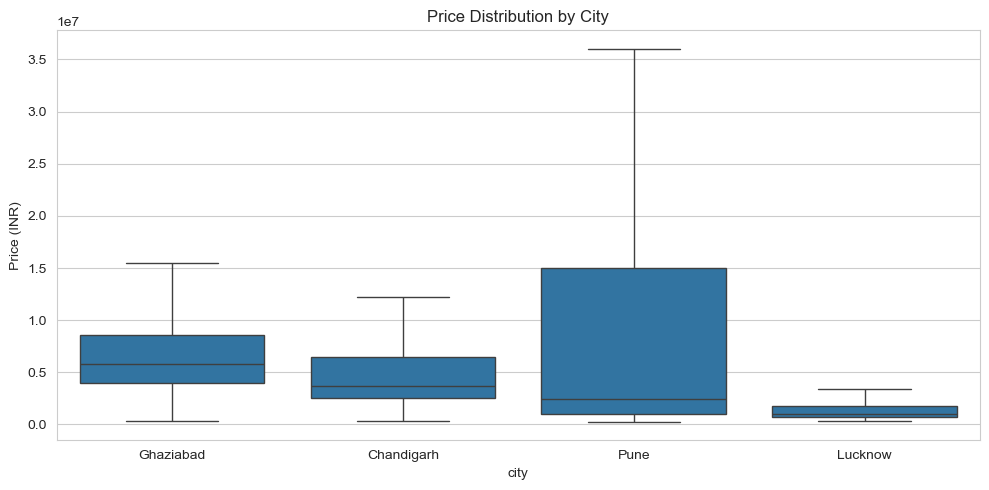

In [3]:
plt.figure(figsize=(10, 5))
order = df.groupby("city")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="city", y="price", order=order, showfliers=False)
plt.title("Price Distribution by City")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.savefig("../reports/figures/price_by_city.png", dpi=120)
plt.show()


## 3. Price by Property Type

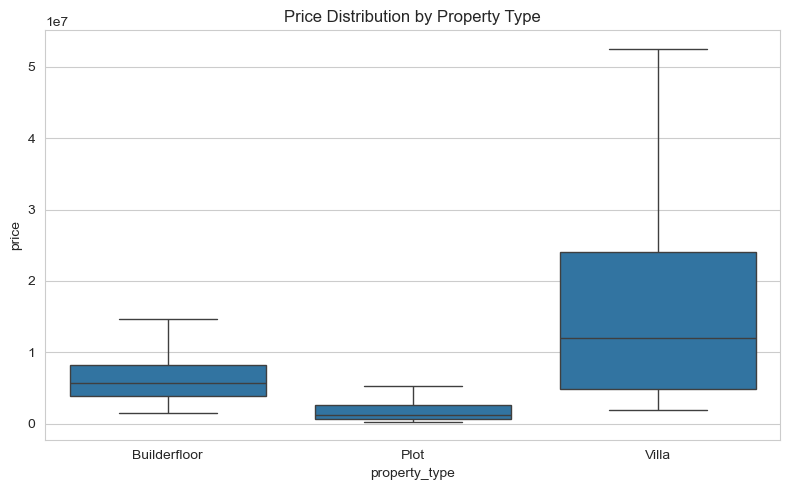

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="property_type", y="price", showfliers=False)
plt.title("Price Distribution by Property Type")
plt.tight_layout()
plt.savefig("../reports/figures/price_by_property_type.png", dpi=120)
plt.show()


## 4. Price per Sqft — City x Property Type

In [5]:
pivot = df.pivot_table(values="price_per_sqft", index="city", columns="property_type", aggfunc="median")
pivot


property_type,Builderfloor,Plot,Villa
city,,,
Chandigarh,3009.710,2833.33,4593.250
Ghaziabad,4827.590,2444.44,3888.890
Lucknow,3954.545,700.00,4160.000
Pune,5327.215,1000.00,7801.555


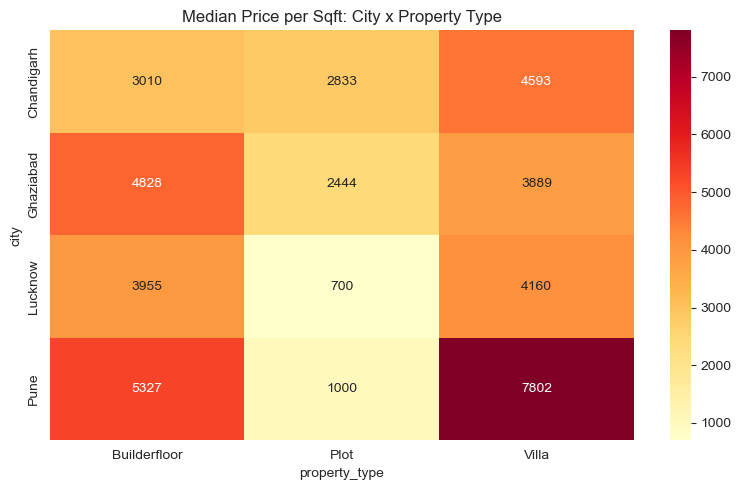

In [6]:
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("Median Price per Sqft: City x Property Type")
plt.tight_layout()
plt.savefig("../reports/figures/price_per_sqft_heatmap.png", dpi=120)
plt.show()


## 5. Area vs Price Relationship

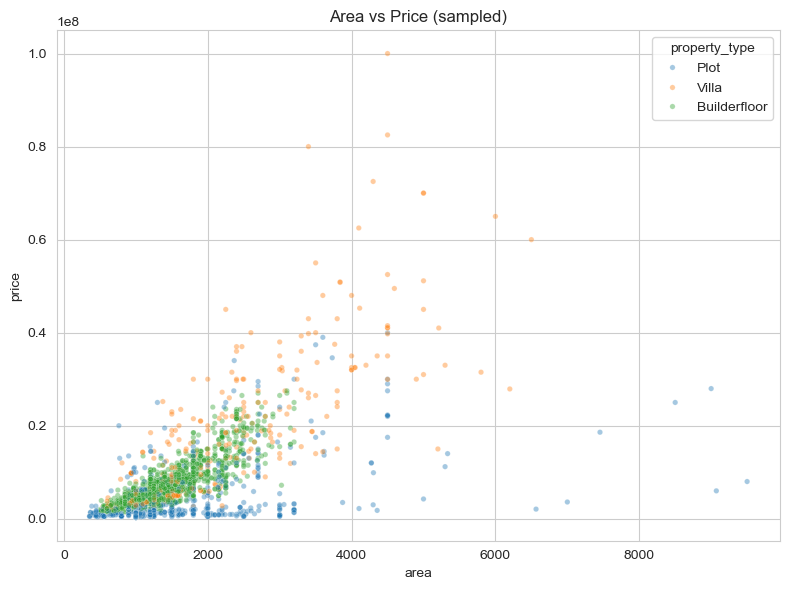

Correlation (area, price): 0.702


In [7]:
plt.figure(figsize=(8, 6))
sample = df.sample(min(3000, len(df)), random_state=42)
sns.scatterplot(data=sample, x="area", y="price", hue="property_type", alpha=0.4, s=15)
plt.title("Area vs Price (sampled)")
plt.tight_layout()
plt.savefig("../reports/figures/area_vs_price.png", dpi=120)
plt.show()

print("Correlation (area, price):", df["area"].corr(df["price"]).round(3))


## 6. Effect of Amenity Count on Price

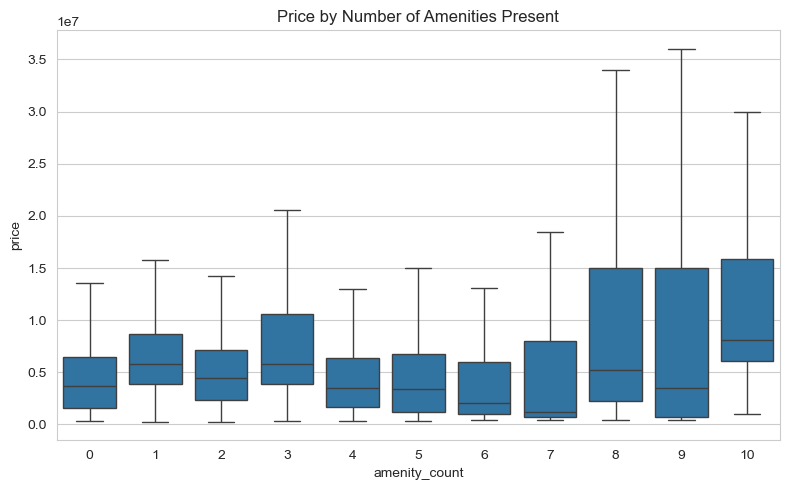

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="amenity_count", y="price", showfliers=False)
plt.title("Price by Number of Amenities Present")
plt.tight_layout()
plt.savefig("../reports/figures/amenity_count_vs_price.png", dpi=120)
plt.show()


## 7. New vs Resale

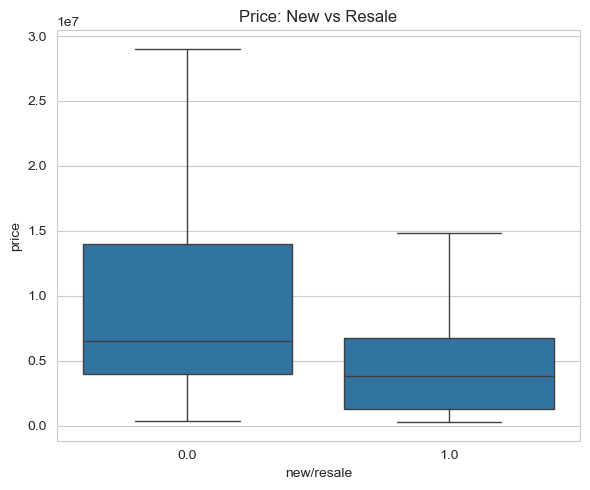

In [9]:
if "new/resale" in df.columns:
    plt.figure(figsize=(6, 5))
    sns.boxplot(data=df, x="new/resale", y="price", showfliers=False)
    plt.title("Price: New vs Resale")
    plt.tight_layout()
    plt.savefig("../reports/figures/new_vs_resale.png", dpi=120)
    plt.show()


## 8. Correlation Heatmap (Numeric Features)

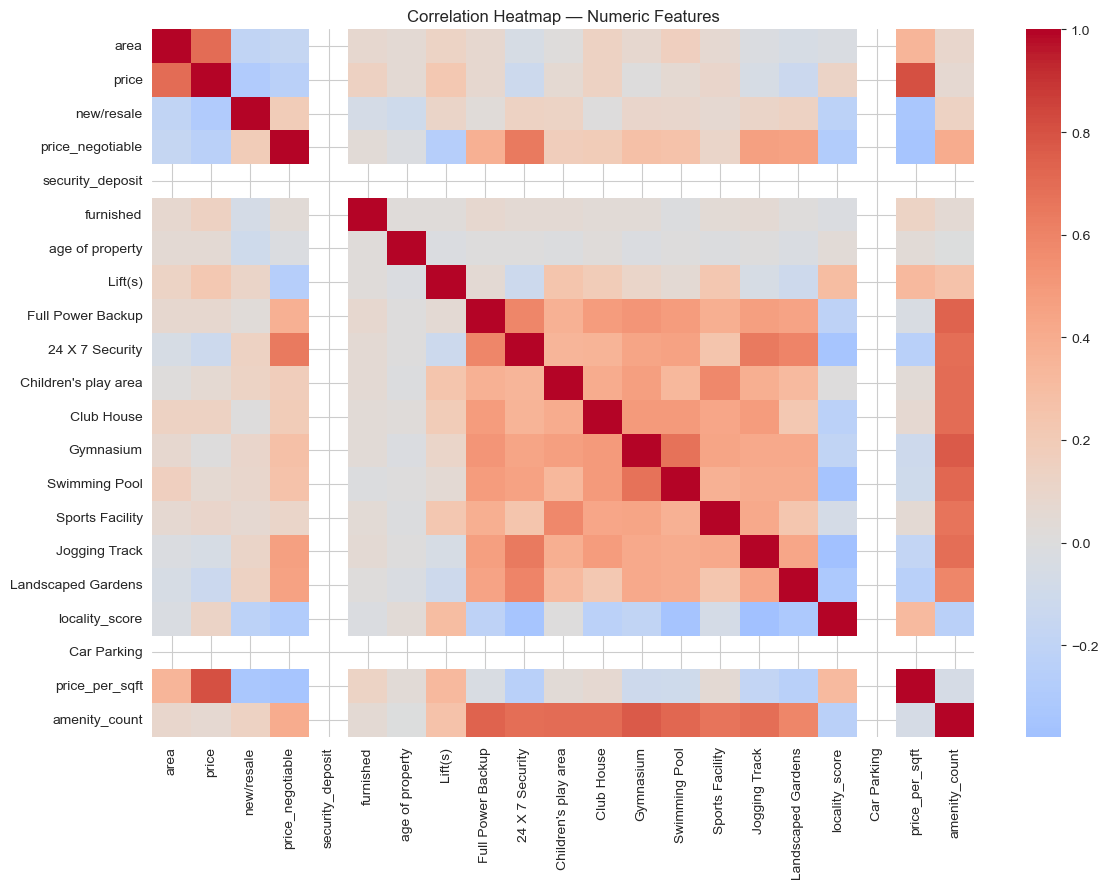

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=120)
plt.show()


## 9. Facing Direction Impact

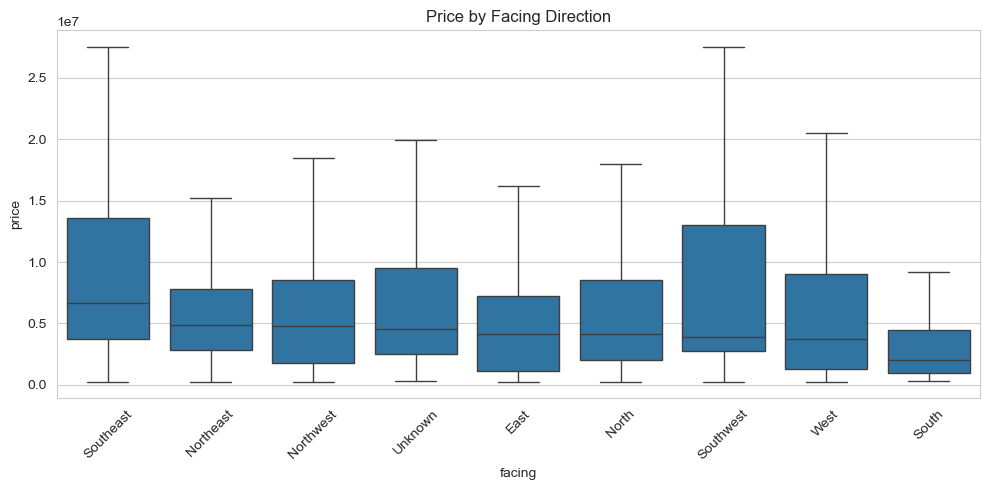

In [11]:
plt.figure(figsize=(10, 5))
order = df.groupby("facing")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="facing", y="price", order=order, showfliers=False)
plt.xticks(rotation=45)
plt.title("Price by Facing Direction")
plt.tight_layout()
plt.savefig("../reports/figures/price_by_facing.png", dpi=120)
plt.show()


## 10. Key EDA Takeaways (fill in after running)
- Which city has the highest median price / price-per-sqft?
- Does more amenities reliably correlate with higher price, or is it dominated by area/location?
- Are there properties/outliers that still look suspicious after cleaning?
- Which features look most useful heading into feature engineering?

*(Write 4-6 bullet points here summarizing what the charts above show, for the report.)*


---
**Next notebook:** `03_feature_engineering.ipynb` — encode categoricals, scale numerics, and prepare the model-ready dataset.
